# Model Evaluation & Error Analysis

This stage evaluates the final tuned Random Forest model on unseen test data and examines how closely the predictions follow actual energy consumption patterns.

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
final_model = joblib.load('../models/final_random_forest.pkl')
test = pd.read_csv('../data/test.csv', parse_dates=['date'])
x_test = test[['date','hour','minute','month','Day_of_week','WeekStatus','lag_1','lag_2','lag_4',
                 'lag_96','lag_672']]
y_test = test['Usage_kWh']
predictions = final_model.predict(x_test)

## Actual vs Predicted Energy Usage

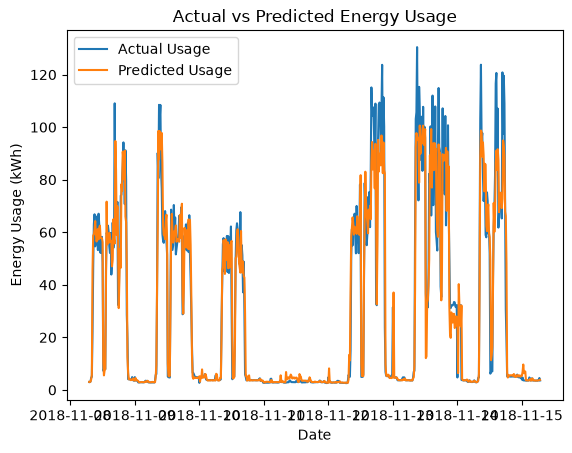

In [4]:
test_plot = test.copy()
test_plot['Predicted_Usage'] = predictions
start_date = test_plot['date'].min()
end_date = start_date + pd.Timedelta(days = 7)

plot_data = test_plot[(test_plot['date'] >= start_date) & (test_plot['date'] < end_date)]

fig, ax = plt.subplots()
sns.lineplot(data = plot_data, x = 'date', y = 'Usage_kWh', label = 'Actual Usage', ax = ax)
sns.lineplot(data = plot_data, x = 'date', y = 'Predicted_Usage', label = 'Predicted Usage', ax = ax)
ax.set_title('Actual vs Predicted Energy Usage')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Usage (kWh)')
ax.legend()

Finding: The actual and predicted energy consumption follow similar patterns throughout the seven-day test period, indicating that the model captures the general temporal structure of energy usage. The predictions track repeated rises and falls in consumption, including periods of lower and higher demand. However, some sharper peaks are smoothed, with actual usage occasionally exceeding the predicted values during high-consumption periods. This indicates that the model captures overall operating patterns but is less responsive to sudden increases in demand.

## Prediction Accuracy Across Energy Usage Levels

Text(0, 0.5, 'Predicted Usage')

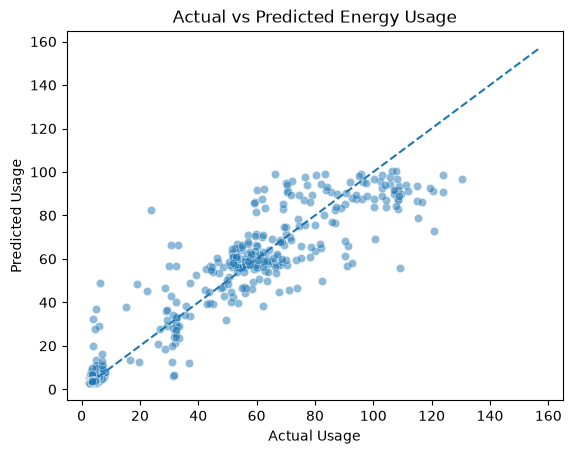

In [5]:
fig, ax = plt.subplots()
sns.scatterplot(data = plot_data, x = 'Usage_kWh', y = 'Predicted_Usage', ax = ax, alpha = 0.5)
min_value = min(test_plot['Usage_kWh'].min(), test_plot['Predicted_Usage'].min())
max_value = max(test_plot['Usage_kWh'].max(), test_plot['Predicted_Usage'].max())
ax.plot([min_value, max_value], [min_value, max_value], linestyle = '--', label = 'Perfect Prediction')
ax.set_title('Actual vs Predicted Energy Usage')
ax.set_xlabel('Actual Usage')
ax.set_ylabel('Predicted Usage')

## Prediction Errors

In [6]:
test_plot['Error'] = test_plot['Usage_kWh'] - test_plot['Predicted_Usage']
test_plot['Absolute_Error'] = test_plot['Error'].abs()

print(f"Mean Error: {test_plot['Error'].mean():.2f} kWh")
print(f"Mean Absolute Error: {test_plot['Absolute_Error'].mean():.2f} kWh")
print(f"Maximum Absolute Error: {test_plot['Absolute_Error'].max():.2f} kWh")

Mean Error: 0.05 kWh
Mean Absolute Error: 4.42 kWh
Maximum Absolute Error: 80.72 kWh


Text(0, 0.5, 'Frequency')

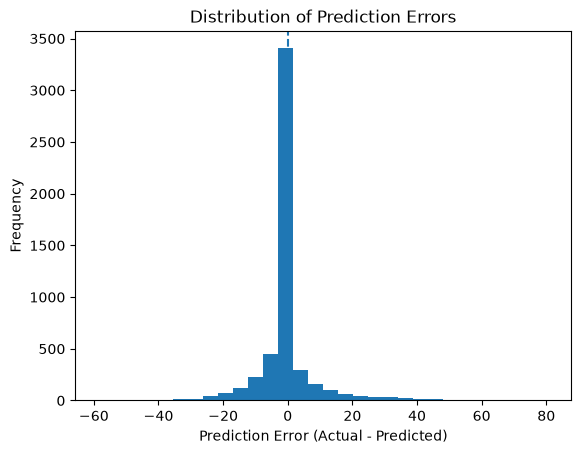

In [7]:
fig, ax = plt.subplots()
ax.hist(test_plot['Error'], bins=30)
ax.axvline(0, linestyle='--')
ax.set_title('Distribution of Prediction Errors')
ax.set_xlabel('Prediction Error (Actual - Predicted)')
ax.set_ylabel('Frequency')

Finding: Prediction errors are centered around zero, indicating that the model does not show a strong overall tendency to consistently overpredict or underpredict energy consumption. However, larger errors occur for some observations, consistent with the model's tendency to smooth more extreme consumption levels.

## Error by Time of Day

Text(0, 0.5, 'Mean Absolute Error (kWh)')

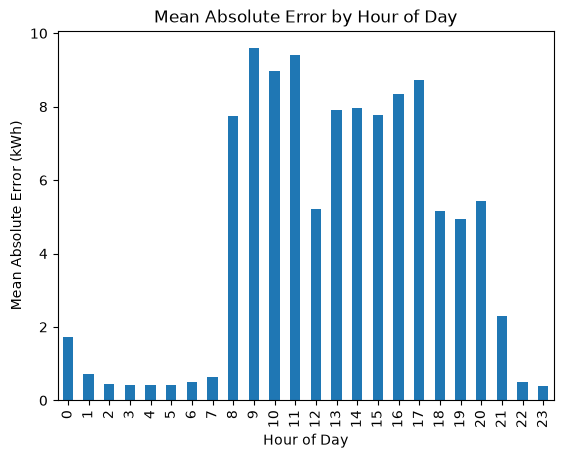

In [8]:
hourly_error = test_plot.groupby('hour')['Absolute_Error'].mean()

fig, ax = plt.subplots()
hourly_error.plot(kind='bar', ax=ax)
ax.set_title('Mean Absolute Error by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Absolute Error (kWh)')

**Finding:** Prediction error varies substantially across the day. Errors are relatively low during overnight hours but increase considerably during the main operating period, particularly between 8:00 and 11:00 and again during the afternoon. The largest errors occur around the morning increase in energy demand, suggesting that the model has greater difficulty predicting periods of rapid changes in consumption.

**Note:** The MAE values are measured in kWh and therefore depend partly on the level of energy consumption during each hour. The higher daytime errors may therefore reflect both greater prediction difficulty and higher overall energy demand.

## Error by Energy Usage Level

In [ ]:
test_plot['Usage_Level'] = pd.qcut(
    test_plot['Usage_kWh'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

usage_level_error = test_plot.groupby('Usage_Level', observed=True)['Absolute_Error'].mean()

usage_level_error

Usage_Level
Low             0.714791
Medium-Low      0.844015
Medium-High     4.737674
High           11.411711
Name: Absolute_Error, dtype: float64

Text(0, 0.5, 'Mean Absolute Error (kWh)')

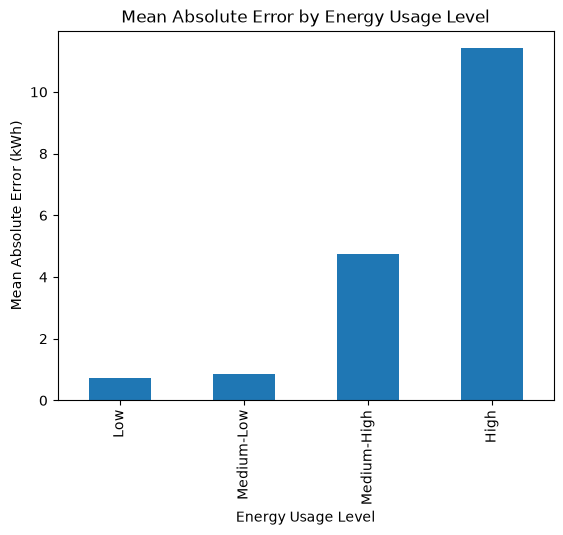

In [10]:
fig, ax = plt.subplots()
usage_level_error.plot(kind='bar', ax=ax)
ax.set_title('Mean Absolute Error by Energy Usage Level')
ax.set_xlabel('Energy Usage Level')
ax.set_ylabel('Mean Absolute Error (kWh)')

**Finding:** Prediction error increases substantially as energy usage increases. The model performs well during low-usage periods, with mean absolute error of 0.72 kWh for the Low group and 0.84 kWh for the Medium-Low group. Error increases to 4.74 kWh for Medium-High usage and 11.41 kWh for High usage. This indicates that the model has greater difficulty predicting periods of high energy consumption, where changes in demand are likely to be more pronounced.

**Note:** These are absolute errors, so higher errors at higher usage levels may partly reflect the larger scale of energy consumption. The results therefore indicate where the largest absolute prediction errors occur but do not by themselves show whether the model is proportionally less accurate at higher loads.

## Feature Importance

In [11]:
rf_model = final_model.named_steps['rfmodel']
preprocessor = final_model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance

numerical__lag_1                      0.883895
numerical__lag_672                    0.027672
numerical__lag_2                      0.023168
numerical__lag_96                     0.022307
numerical__hour                       0.012022
numerical__lag_4                      0.011072
numerical__month                      0.008645
numerical__minute                     0.005567
categorical__Day_of_week_Monday       0.001259
categorical__WeekStatus_Weekday       0.001120
categorical__WeekStatus_Weekend       0.001014
categorical__Day_of_week_Thursday     0.000584
categorical__Day_of_week_Tuesday      0.000516
categorical__Day_of_week_Friday       0.000437
categorical__Day_of_week_Wednesday    0.000373
categorical__Day_of_week_Saturday     0.000263
categorical__Day_of_week_Sunday       0.000088
dtype: float64

Text(0, 0.5, 'Feature')

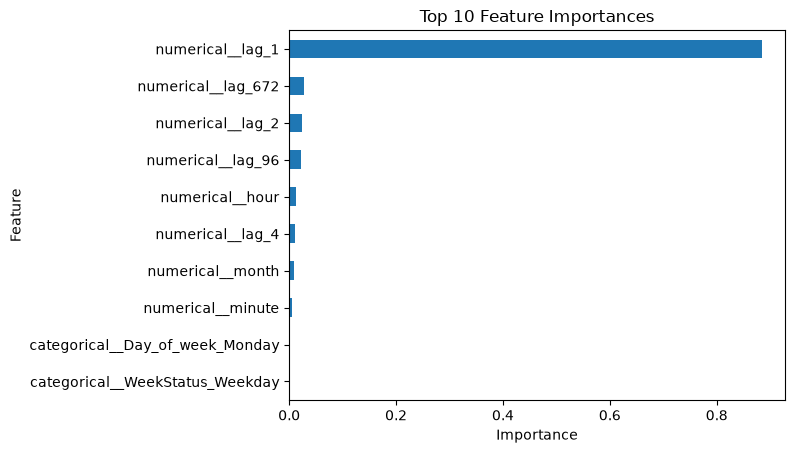

In [12]:
fig, ax = plt.subplots()
importance.head(10).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')

**Finding:** The model relies heavily on recent energy consumption, with `lag_1` accounting for approximately 88.4% of the model's feature importance. The weekly, 30-minute, and daily lag features provide smaller additional contributions, while time-based and categorical features have relatively low importance. This indicates that the most recent energy consumption is the strongest predictor of the next 15-minute usage, consistent with the strong short-term autocorrelation observed during EDA.

The dominance of `lag_1` also helps explain the model's behaviour in the error analysis. When consumption changes rapidly, relying heavily on the most recent observation can result in larger prediction errors, particularly during periods of high or rapidly changing demand.

**Note:** Feature importance is based on the Random Forest's impurity-based importance measure. Because several lag features are correlated, importance may be distributed unevenly among them. The results therefore indicate which features the model relies on most, rather than establishing that a feature independently causes better predictions.

## Limitations

The forecasting model has several limitations. The dataset contains energy and operating measurements from a single steel-industry site and covers one year, so the results may not generalize to other facilities or operating conditions. The model also relies heavily on recent energy consumption, which limits its ability to anticipate sudden changes in demand. This is reflected in the larger prediction errors observed during high-consumption periods.

The analysis is based only on the variables available in the dataset. External factors such as production schedules, holidays, maintenance activities, or other operational events were not available and therefore could not be incorporated into the forecast.

Finally, model performance was evaluated using historical test data. Performance in a live forecasting environment may differ as operating conditions change over time.

## Conclusion

The final Random Forest model provides a useful short-term forecast of energy consumption 15 minutes ahead. On the unseen test set, it achieved a MAE of 4.42 kWh and an RMSE of 9.39 kWh, representing improvements of 12.2% and 19.5%, respectively, over the persistence baseline.

The evaluation shows that the model captures the general temporal pattern of energy consumption, while its largest errors occur during periods of higher and rapidly changing demand. Feature importance analysis also shows that recent energy consumption is the dominant predictor of the next 15-minute value.

Overall, the results demonstrate that historical consumption and basic temporal features can provide a practical basis for short-term energy forecasting, while also highlighting opportunities for future improvement through additional operational information and features that better capture rapid changes in demand.